---
title: Simulate neutron scattering in quantum materials with quantum circuits
description: Compute the dynamical structure factor of a quantum magnet using Trotter circuits and MPS simulation.
---

{/* cspell:ignore DSFs spinon Cloizeaux DMRG eigsh viridis fontsize vmax vmin Aer's cadetblue */}

# Simulate neutron scattering in quantum materials with quantum circuits

*Usage estimate: 13 minutes on a Heron r2 processor (NOTE: This is an estimate only. Your runtime might vary.)*

## Learning outcomes

After completing this tutorial, you can expect to understand the following information:
- How inelastic neutron scattering (INS) spectra connect to dynamical structure factors (DSFs) of quantum spin models.
- How to prepare a ground state, apply a local perturbation, and perform Trotter time evolution on a quantum circuit.
- How to use approximate quantum compiling (AQC) with `qiskit-addon-aqc-tensor` to compress deep Trotter circuits for hardware execution.
- How to extract the retarded Green's function (RGF) from qubit expectation values and Fourier-transform it into a DSF.

## Prerequisites
It is recommended that you familiarize yourself with these topics:
- [Basics of Quantum Circuits and Gates](https://learning.quantum.ibm.com/course/basics-of-quantum-information)
- [Variational Algorithms and Hamiltonian Simulation](https://learning.quantum.ibm.com/course/variational-algorithm-design)
- [Introduction to Qiskit Primitives (Estimator & Sampler)](https://docs.quantum.ibm.com/guides/primitives)

## Background

In this tutorial, we reproduce the results of [Lee et al., arXiv:2603.15608](https://arxiv.org/abs/2603.15608) at a smaller scale. While that paper ran a 50-qubit experiment, here we run a 20-qubit experiment to keep the cost of performing approximate quantum compilation (AQC) more manageable.

### Inelastic neutron scattering and the dynamical structure factor

Inelastic neutron scattering (INS) is one of the most powerful experimental probes of magnetic excitations in quantum materials. When a beam of thermal or cold neutrons impinges on a crystal, individual neutrons exchange both momentum $\mathbf{q}$ and energy $\omega$ with the magnetic subsystem. The measured scattering intensity is proportional to the dynamical structure factor (DSF),

$$S^{\alpha\beta}(q,\omega) = \sum_{j} e^{-iq\,j}\int_{-\infty}^{\infty} dt\; e^{i\omega t}\, \langle S_0^{\alpha}(0)\, S_j^{\beta}(t)\rangle,$$

which encodes the full space-time correlations of the spin degrees of freedom.

### KCuF$_3$ — a canonical Luttinger-liquid magnet

Potassium copper fluoride (KCuF$_3$) is a quasi-one-dimensional antiferromagnet in which chains of spin-$\frac{1}{2}$ Cu$^{2+}$ ions interact via a nearest-neighbor Heisenberg exchange $J \approx 34\;\mathrm{meV}$, while the interchain coupling is only $\sim 2.7\%$ of $J$. At $T = 6\;\mathrm{K}$ where INS data are available, the spectrum is dominated by fractionalized spinon excitations characteristic of a Tomonaga-Luttinger liquid. Because the intrachain dynamics are well described by the one-dimensional spin-$\frac{1}{2}$ XXZ Hamiltonian at the isotropic point ($\epsilon = 1$),

$$H = J\sum_{i}\left[S_i^Z S_{i+1}^Z + \epsilon\left(S_i^X S_{i+1}^X + S_i^Y S_{i+1}^Y\right)\right],$$

KCuF$_3$ serves as an ideal benchmark for quantum simulation: the Hamiltonian is simple enough to implement on a quantum processor, yet the ground state is strongly entangled and the excitation spectrum features a broad two-spinon continuum.

### What we simulate and measure

The physical quantity we compute is the **retarded Green's function** (RGF), defined as the time-dependent spin–spin correlation function

$$G^R_{\alpha\beta}(j, j_c, t) = -i\,\theta(t)\,\langle\psi_{\mathrm{GS}}|\,[S_j^\alpha(t),\, S_{j_c}^\beta(0)]\,|\psi_{\mathrm{GS}}\rangle,$$

where $j_c$ is a reference site (the chain center) and $S_j^\alpha(t) = e^{iHt}S_j^\alpha e^{-iHt}$ is the Heisenberg-picture spin operator. In this tutorial we focus on the $zz$ component ($\alpha = \beta = z$). On a quantum computer the RGF is accessed by preparing the ground state, applying a local perturbation at $j_c$, time-evolving the perturbed state, and measuring the single-qubit expectation value $\langle\sigma_j^z\rangle$ at every site $j$ for each time step. The key insight is that each $\langle\sigma_j^z\rangle$ gives the difference from the ground-state magnetization; because the isotropic Heisenberg antiferromagnet has zero net per-site magnetization ($\langle\sigma_j^z\rangle_\mathrm{GS} = 0$), the raw measured value directly yields $G^R(j, j_c, t)$ without any explicit subtraction.

By collecting $G^R(j, j_c, t)$ over all sites and time steps, we assemble a two-dimensional dataset that is then Fourier-transformed in both space and time to produce the **dynamical structure factor** $S(q,\omega)$. The DSF is the quantity directly measured in an INS experiment: it tells us what magnetic excitations exist at each momentum $q$ and energy $\omega$. For the isotropic Heisenberg chain the exact excitation spectrum is a **two-spinon continuum** — a broad band of scattering intensity whose shape serves as a stringent end-to-end benchmark for the quantum simulation: it validates the ground-state preparation, perturbation, Trotter time evolution, and measurement protocol all at once.

### Quantum-simulation workflow

The workflow mirrors the physics of an INS event. We (1) prepare the many-body ground state $|\psi_{\mathrm{GS}}\rangle$ on $n$ qubits, (2) apply a local spin-flip perturbation $U_{j_c} = \frac{1}{\sqrt{2}}(I - i\sigma^z_{j_c})$ at the chain center to mimic the neutron's spin transfer, (3) evolve under $H$ for discrete time steps using second-order Trotterization, and (4) measure $\langle\sigma_i^z\rangle$ on every qubit at each step to obtain the RGF. A two-dimensional discrete Fourier transform then yields the DSF $S(q,\omega)$.

The observable we measure at every time step is $\sigma_i^z$ on each qubit $i$. In Qiskit this is represented as a list of `SparsePauliOp` operators — one single-qubit $Z$ embedded in the $n$-qubit identity string for each site. These observables are constructed once per problem instance during the problem-mapping step (Step 1) and reused for every circuit at that scale.

### Approximate quantum compiling (AQC)

Deep Trotter circuits can be compressed with **approximate quantum compiling (AQC)**, which replaces the first several Trotter layers with a shorter parameterized ansatz whose parameters are classically optimized to maximize the MPS-level fidelity with the original deep circuit. The remaining Trotter steps are appended exactly, producing a "mixed" AQC + Trotter circuit with substantially fewer two-qubit gates. In this tutorial AQC is demonstrated at small scale in Step 2 and scaled up in the large-scale section.

### MPS simulation

For a one-dimensional system, matrix-product-state (MPS) methods can efficiently simulate both ground-state preparation (via DMRG) and circuit-level time evolution. By controlling the bond dimension $\chi$, one trades off accuracy against computational cost. In this tutorial we use MPS simulation within `qiskit-addon-aqc-tensor` to compute high-fidelity AQC ansätze that compress the deep Trotter circuits for hardware execution.

## Requirements
Before starting this tutorial, be sure you have the following installed:

- Qiskit SDK with visualization extras (`pip install qiskit[visualization]`)
- Qiskit Runtime (`pip install qiskit-ibm-runtime`)
- qiskit-addon-aqc-tensor with quimb and JAX extras (`pip install 'qiskit-addon-aqc-tensor[quimb-jax]'`)

## Setup

In [1]:
import timeit
import warnings
from collections.abc import Iterator, Sequence
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import quimb.tensor as qtn
import scipy.optimize
from numpy.typing import NDArray
from qiskit import QuantumCircuit
from qiskit.circuit import CircuitInstruction, ParameterVector, Qubit
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_addon_aqc_tensor import generate_ansatz_from_circuit
from qiskit_addon_aqc_tensor.objective import MaximizeStateFidelity
from qiskit_addon_aqc_tensor.simulation import tensornetwork_from_circuit
from qiskit_addon_aqc_tensor.simulation.quimb import QuimbSimulator
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_quimb import quimb_circuit
from scipy.sparse import SparseEfficiencyWarning

# scipy.sparse.linalg.expm (reached via PauliEvolutionGate.to_matrix) prefers
# CSC and warns when handed the CSR matrix from SparsePauliOp.to_matrix; the
# result is unaffected, so silence the cosmetic warning.
warnings.filterwarnings("ignore", category=SparseEfficiencyWarning)


# ════════════════════════════════════════════════════════════
#  Hamiltonian and ground state via DMRG
# ════════════════════════════════════════════════════════════


def xxz_hamiltonian_mpo(
    n_qubits: int, coupling: float = 1.0, anisotropy: float = 1.0
) -> qtn.MatrixProductOperator:
    """1D XXZ Hamiltonian as a quimb MPO.

    Builds the Hamiltonian using ``qtn.SpinHam1D``.

    Args:
        n_qubits: Number of sites.
        coupling: Overall coupling strength (J in the paper).
        anisotropy: XY/Z anisotropy (ε in the paper). ``ε = 1`` is the
            isotropic Heisenberg point; ``ε = 0`` is the Ising limit.

    Returns:
        The Hamiltonian as a matrix product operator.
    """
    builder = qtn.SpinHam1D(S=1 / 2)
    builder += coupling * anisotropy * 0.5, "+", "-"
    builder += coupling * anisotropy * 0.5, "-", "+"
    builder += coupling, "Z", "Z"
    return builder.build_mpo(L=n_qubits)


# ════════════════════════════════════════════════════════════
#  Trotter circuit builder (2nd-order Suzuki-Trotter)
# ════════════════════════════════════════════════════════════


def trotter_evolution(
    qubits: Sequence[Qubit],
    coupling: float,
    anisotropy: float,
    time_step: float,
    n_steps: int,
) -> Iterator[CircuitInstruction]:
    """Second-order Trotter steps of the XXZ pair Hamiltonian.

    While the paper used a hand-optimized circuit for the Trotter steps, we use
    PauliEvolutionGate here for simplicity and generality. The final two-qubit gate
    count and gate depth are equivalent when transpiled with ``optimization_level=3``.

    Args:
        qubits: Qubits to act on (length ``n_qubits``).
        coupling: Overall coupling strength (J in the paper).
        anisotropy: XY/Z anisotropy (ε in the paper). ``ε = 1`` is the
            isotropic Heisenberg point; ``ε = 0`` is the Ising limit.
        time_step: Per-step Trotter time.
        n_steps: Number of Trotter steps.

    Yields:
        ``CircuitInstruction``s implementing the Trotter steps.
    """
    if n_steps == 0:
        return
    n_qubits = len(qubits)
    pair_ham = SparsePauliOp(
        ["XX", "YY", "ZZ"],
        coeffs=[
            0.25 * coupling * anisotropy,
            0.25 * coupling * anisotropy,
            0.25 * coupling,
        ],
    )
    half_evo = PauliEvolutionGate(pair_ham, time=time_step / 2)
    full_evo = PauliEvolutionGate(pair_ham, time=time_step)
    for i in range(n_qubits // 2):  # half even layer
        yield CircuitInstruction(half_evo, (qubits[2 * i], qubits[2 * i + 1]))
    for i in range(n_qubits // 2 - 1):  # full odd layer
        yield CircuitInstruction(
            full_evo, (qubits[2 * i + 1], qubits[2 * i + 2])
        )
    for _ in range(n_steps - 1):  # interior steps
        for i in range(n_qubits // 2):
            yield CircuitInstruction(
                full_evo, (qubits[2 * i], qubits[2 * i + 1])
            )
        for i in range(n_qubits // 2 - 1):
            yield CircuitInstruction(
                full_evo, (qubits[2 * i + 1], qubits[2 * i + 2])
            )
    for i in range(n_qubits // 2):  # half even layer
        yield CircuitInstruction(half_evo, (qubits[2 * i], qubits[2 * i + 1]))


# ════════════════════════════════════════════════════════════
#  DSF via discrete Fourier transform
# ════════════════════════════════════════════════════════════


def get_dsf(
    n_qubits: int,
    rgf_mat: NDArray[np.floating],
    time_step: float,
    n_steps: int,
    n_points_momentum: int,
    n_points_frequency: int,
) -> NDArray[np.floating]:
    """Compute the dynamical structure factor from the retarded Green's function.

    Uses the center-site approximation and a discrete Fourier transform.
    The result is symmetrized about the momentum axis and clipped to
    non-negative values, ready for plotting.

    Args:
        n_qubits: Number of qubits (sites).
        rgf_mat: RGF matrix of shape ``(n_steps, n_qubits)``.
        time_step: Trotter time-step size.
        n_steps: Number of time steps.
        n_points_momentum: Number of momentum points.
        n_points_frequency: Number of frequency points.

    Returns:
        DSF array of shape ``(n_points_frequency, n_points_momentum)``,
        symmetrized about the momentum axis and clipped to non-negative values.
    """
    green = rgf_mat / 4  # two spin operators (sigma/2)(sigma/2) -> factor 1/4
    max_frequency = np.pi / time_step
    momentum_range = np.linspace(0, 2 * np.pi, n_points_momentum)
    frequency_range = np.linspace(0, max_frequency, n_points_frequency)
    result = np.zeros((frequency_range.shape[0], momentum_range.shape[0]))
    center = n_qubits // 2 - 1
    for iw, w in enumerate(frequency_range):
        exponent = np.exp(1j * w * time_step * np.arange(1, n_steps + 1))
        green_omega = (
            np.dot(green.T, exponent) * time_step
        )  # S(omega): time Fourier slice of the Green's function
        for iq, q in enumerate(momentum_range):
            momentum_phases = np.exp(-1j * q * np.arange(-center, center + 2, 1))
            result[iw, iq] = np.imag(np.dot(green_omega, momentum_phases))
    result = -(result + result[:, ::-1]) / 2
    result = np.clip(result, a_min=0, a_max=None)
    return result


# ════════════════════════════════════════════════════════════
#  Plotting helpers
# ════════════════════════════════════════════════════════════


def plot_dsf(
    dsf: NDArray[np.floating],
    time_step: float,
    n_points_momentum: int,
    n_points_frequency: int,
    title: str | None = None,
) -> None:
    """Heat-map of the dynamical structure factor.

    Args:
        dsf: DSF array of shape ``(n_points_frequency, n_points_momentum)``.
        time_step: Trotter time-step size.
        n_points_momentum: Number of momentum points.
        n_points_frequency: Number of frequency points.
        title: Optional plot title.
    """
    max_frequency = np.pi / time_step
    momentum_range = np.linspace(0, 2 * np.pi, n_points_momentum)
    frequency_range = np.linspace(0, max_frequency, n_points_frequency)
    x, y = np.meshgrid(momentum_range, frequency_range)
    fig, ax = plt.subplots(figsize=(8, 5))
    c = ax.pcolormesh(x, y, dsf / np.max(dsf), cmap="viridis", shading="auto")
    fig.colorbar(c, ax=ax, label="Normalized intensity")
    ax.set_ylim(0, 3.6)
    ax.set_xlim(0, 2 * np.pi)
    ax.set_xlabel(r"$q$", fontsize=16)
    ax.set_ylabel(r"$\tilde{\omega} = \omega / J$", fontsize=16)
    ax.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
    ax.set_xticklabels(["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
    if title:
        ax.set_title(title, fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_rgf(
    n_qubits: int,
    rgf_mat: NDArray[np.floating],
    time_step: float,
    n_steps: int,
    title: str | None = None,
) -> None:
    """Heat-map of the retarded Green's function in real space and time.

    Args:
        n_qubits: Number of qubits (sites).
        rgf_mat: RGF matrix of shape ``(n_steps, n_qubits)``.
        time_step: Trotter time-step size.
        n_steps: Number of time steps.
        title: Optional plot title.
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    qubit_axis = np.arange(n_qubits)
    t_axis = np.arange(1, n_steps + 1) * time_step
    x, y = np.meshgrid(qubit_axis, t_axis)
    c = ax.pcolormesh(
        x,
        y,
        np.real(rgf_mat),
        cmap="RdBu",
        vmax=0.5,
        vmin=-0.5,
        shading="auto",
    )
    fig.colorbar(c, ax=ax, label=r"Re $G^R(j, j_c, t)$")
    ax.set_xlabel("Qubit", fontsize=16)
    ax.xaxis.set_major_locator(
        plt.matplotlib.ticker.MaxNLocator(integer=True)
    )
    ax.set_ylabel(r"Time", fontsize=16)
    if title:
        ax.set_title(title, fontsize=14)
    plt.tight_layout()
    plt.show()


# ════════════════════════════════════════════════════════════
#  Variational ground-state ansatz (HVA)
# ════════════════════════════════════════════════════════════


def build_ground_state_ansatz(n_qubits: int, n_layers: int) -> QuantumCircuit:
    """Hamiltonian variational ansatz (HVA) circuit for ground-state preparation.

    Starts from a product of singlet pairs and applies alternating
    odd/even layers of parameterized XXZ pair-evolution gates.

    The returned circuit is parameterized: it carries a ``ParameterVector``
    named ``"theta"`` of length ``2 * n_layers`` whose values must be
    assigned (e.g. via ``circuit.assign_parameters``) before simulation.
    Element ``2 * r`` is the odd-layer angle and element ``2 * r + 1`` is the
    even-layer angle of layer ``r``.

    Args:
        n_qubits: Number of qubits (must be even).
        n_layers: Number of HVA layers.

    Returns:
        The parameterized HVA preparation circuit.
    """
    theta = ParameterVector("theta", 2 * n_layers)
    circuit = QuantumCircuit(n_qubits)
    # Initial singlet product state
    for i in range(n_qubits // 2):
        circuit.x(2 * i)
        circuit.x(2 * i + 1)
        circuit.h(2 * i + 1)
        circuit.cx(2 * i + 1, 2 * i)
    # Variational layers: each pair gate is exp(-i theta (XX+YY+ZZ)/2)
    pair_ham = SparsePauliOp(
        ["XX", "YY", "ZZ"], coeffs=[0.5, 0.5, 0.5]
    )  # H_pair (HVA form)
    for r in range(n_layers):
        for i in range(1, (n_qubits + 1) // 2):  # odd layer
            circuit.append(
                PauliEvolutionGate(pair_ham, time=theta[2 * r]),
                [2 * i - 1, 2 * i],
            )
        for i in range(n_qubits // 2):  # even layer
            circuit.append(
                PauliEvolutionGate(pair_ham, time=theta[2 * r + 1]),
                [2 * i, 2 * i + 1],
            )
    return circuit


def optimize_ground_state_ansatz(
    ansatz: QuantumCircuit,
    x0: NDArray[np.floating],
    target_mps: qtn.MatrixProductState,
    *,
    max_bond: int | None = None,
    cutoff: float = 1e-10,
    method: str = "COBYQA",
    options: dict | None = None,
) -> scipy.optimize.OptimizeResult:
    """Optimize HVA parameters by maximizing fidelity with a target MPS.

    The HVA circuit is simulated as a matrix product state with the given
    bond-dimension truncation, and the parameters are optimized to maximize
    the state fidelity ``|<psi_HVA | target_mps>|**2`` with the DMRG ground
    state. Both states are normalized, so the minimized objective is the
    infidelity ``1 - |<psi_HVA | target_mps>|**2``.

    Args:
        ansatz: Parameterized HVA circuit from ``build_ground_state_ansatz``.
            The length of ``x0`` must equal ``ansatz.num_parameters``.
        x0: Initial parameters.
        target_mps: Target MPS (DMRG ground state) to maximize fidelity with.
        max_bond: Maximum MPS bond dimension during gate application.
        cutoff: Singular-value cutoff during gate application.
        method: ``scipy.optimize.minimize`` method.
        options: Options dict forwarded to ``scipy.optimize.minimize``.

    Returns:
        The Scipy OptimizeResult.
    """

    def infidelity(params: NDArray[np.floating]) -> float:
        circuit = ansatz.assign_parameters(params)
        circuit_mps = quimb_circuit(
            circuit.decompose(["PauliEvolution"]),
            quimb_circuit_class=qtn.CircuitMPS,
            max_bond=max_bond,
            cutoff=cutoff,
        )
        return 1 - abs(circuit_mps.psi.H @ target_mps) ** 2

    return scipy.optimize.minimize(
        infidelity, np.asarray(x0), method=method, options=options
    )


def uniform_2q_depth(circuit: QuantumCircuit) -> int:
    """Two-qubit gate depth in a standardized basis."""
    pass_manager = generate_preset_pass_manager(
        optimization_level=0, basis_gates=["cz", "id", "rz", "sx", "x"]
    )
    return pass_manager.run(circuit).depth(
        lambda inst: inst.operation.num_qubits == 2
    )


## Small-scale simulator example

We first demonstrate the full workflow on **10 qubits**, optimizing the HVA ground-state ansatz via MPS simulation and using Qiskit's statevector simulator for time evolution. DMRG gives a reference ground-state energy and MPS. This small-scale example lets us validate every step before scaling up.

### Step 1: Map classical inputs to a quantum problem

We begin by defining the physical model and constructing the quantum circuits.

**Hamiltonian.** KCuF$_3$ is modelled by the 1D XXZ Hamiltonian at the isotropic point ($J = 1$, $\epsilon = 1$, setting $J = 1$ as the energy unit).

**Ground state.** We use a Hamiltonian variational ansatz (HVA) circuit, `build_ground_state_ansatz`, as the ground-state preparation circuit. The HVA parameters are optimized classically by maximizing the state fidelity $|\langle\psi_{\mathrm{HVA}}(\theta)|\psi_{\mathrm{DMRG}}\rangle|^2$ with the DMRG ground-state MPS, where the HVA state is evaluated by simulating the circuit as a matrix product state with quimb's `CircuitMPS`. We use `scipy.optimize.minimize` for the optimization. The energy $\langle H \rangle$ of the optimized ansatz is also computed for reference.

**Trotter gates.** Each nearest-neighbor interaction term $e^{-i\Delta t\, H_{\mathrm{pair}}}$ with $H_{\mathrm{pair}} = (J/4)(XX + YY + ZZ)$ is constructed via `PauliEvolutionGate(H_pair, time=time_step)`. Qiskit synthesizes this into the optimal three-CNOT decomposition during transpilation.

**Perturbation.** An $R_z(\pi/2)$ gate on the center qubit implements $U_{j_c} = \frac{1}{\sqrt{2}}(I - i\sigma^z_{j_c})$, mimicking the local spin-flip produced by a scattered neutron.

**Observables.** We construct a $\sigma^z$ observable for each qubit site. These `SparsePauliOp` objects are passed to the Estimator primitive in Step 3 to extract $\langle\sigma_i^z\rangle$ at every time step.


In [2]:
# -- Physical parameters --
n_qubits = 10
coupling = 1.0  # J
anisotropy = 1.0  # ε (isotropic point)
time_step = 0.6
n_steps = 10
mps_max_bond = 32
mps_cutoff = 1e-8
center = n_qubits // 2 - 1

# -- Hamiltonian MPO --
ham_mpo = xxz_hamiltonian_mpo(n_qubits, coupling, anisotropy)

# -- Reference ground-state energy via DMRG --
dmrg = qtn.DMRG2(ham_mpo)
dmrg.solve(tol=1e-8)
print(f"Ground-state energy (DMRG): {dmrg.energy:.6f}")

# -- Build ground state ansatz circuit --
gs_n_layers = 3
gs_ansatz = build_ground_state_ansatz(n_qubits, gs_n_layers)

# -- Optimize ground state ansatz parameters to maximize fidelity with the DMRG MPS --
# Initialize odd-layer angles near 0 (where the inter-pair gate is the
# identity) and even-layer angles near pi/2 (where the intra-pair gate
# is a SWAP, since 0.5*(XX + YY + ZZ) = SWAP - I/2).
rng = np.random.default_rng(12345)
x0_init = np.tile([0, np.pi / 2], gs_n_layers) + rng.normal(
    scale=0.1, size=2 * gs_n_layers
)
print("Optimizing ground state ansatz...")
t0 = timeit.default_timer()
result = optimize_ground_state_ansatz(
    gs_ansatz,
    x0_init,
    dmrg.state,
    max_bond=mps_max_bond,
    cutoff=mps_cutoff,
    options=dict(maxiter=100),
)
t1 = timeit.default_timer()
print(f"Finished optimizing ground state ansatz in {t1 - t0} seconds.")
print(f"Ground state ansatz fidelity: {1 - result.fun:.6f}")

gs_circuit = gs_ansatz.assign_parameters(result.x)
gs_circuit_mps = quimb_circuit(
    gs_circuit.decompose(["PauliEvolution"]),
    quimb_circuit_class=qtn.CircuitMPS,
    max_bond=mps_max_bond,
    cutoff=mps_cutoff,
)
gs_ansatz_energy = qtn.expec_TN_1D(
    gs_circuit_mps.psi.H, ham_mpo, gs_circuit_mps.psi
)
print(f"Ground state ansatz energy: {gs_ansatz_energy:.6f}")

# -- Build circuits for each time step --
perturbed = gs_circuit.copy()
perturbed.rz(np.pi / 2, center)

circuits = []
for t in range(1, n_steps + 1):
    circuit = perturbed.copy()
    for instr in trotter_evolution(
        circuit.qubits, coupling, anisotropy, time_step, t
    ):
        circuit.append(instr)
    circuits.append(circuit)
print(
    f"Built {len(circuits)} circuits, deepest 2q depth (uniform basis) = "
    f"{uniform_2q_depth(circuits[-1])}"
)

# -- Observables: Z on each qubit site --
observables = [
    SparsePauliOp.from_sparse_list([("Z", [i], 1)], num_qubits=n_qubits)
    for i in range(n_qubits)
]
print(f"Defined {len(observables)} Z observables.")


Ground-state energy (DMRG): -4.258035
Optimizing ground state ansatz...
Finished optimizing ground state ansatz in 8.773147442028858 seconds.
Ground state ansatz fidelity: 0.984636
Ground state ansatz energy: -4.232891
Built 10 circuits, deepest 2q depth (uniform basis) = 163
Defined 10 Z observables.


### Step 2: Optimize problem for quantum hardware execution

For real hardware, the Trotter circuits above would be too deep. **Approximate Quantum Compiling (AQC)** addresses this by replacing the first $k$ Trotter layers (including the ground-state circuit) with a shorter parameterized ansatz optimized to maximize the MPS-level fidelity with the original deep circuit. The remaining Trotter steps are appended exactly, producing a shallower "AQC + Trotter" circuit.

To balance expressibility against circuit depth, two ansätze are used: a **one-layer ansatz** (generated from a single Trotter step) compresses the earliest time steps, and a deeper **two-layer ansatz** (generated from two Trotter steps) compresses the next few steps where higher fidelity is needed.

The AQC workflow has four sub-steps:

1. **Build target circuits** — the first $k_1 + k_2$ circuits from Step 1 serve directly as AQC targets.
2. **Compute target MPS** — simulate each target circuit as a matrix-product state using `quimb.tensor.CircuitMPS`.
3. **Generate and optimize ansätze** — `generate_ansatz_from_circuit` creates a one-layer and a two-layer parameterized ansatz; parameters are optimized via L-BFGS-B with JAX-accelerated gradients to minimize $1 - |\langle\psi_{\mathrm{ansatz}}|\psi_{\mathrm{target}}\rangle|^2$. The first $k_1$ steps use the one-layer ansatz and the next $k_2$ steps use the two-layer ansatz; within each stage, each step warm-starts from the previous step's optimized parameters, and parameters are reset to the stage defaults at the stage boundary.
4. **Assemble mixed circuits** — for time steps beyond the AQC checkpoint, append exact Trotter layers to the optimized two-layer AQC circuit using `trotter_evolution`.



Step 2b — target MPS:
  k=1: max bond = 22
  k=2: max bond = 23
  k=3: max bond = 26
  k=4: max bond = 27
  k=5: max bond = 30

Step 2c — one-layer ansatz: 389 parameters, 2q depth (uniform basis) = 27
Step 2c — two-layer ansatz: 470 parameters, 2q depth (uniform basis) = 33
  k=1: fidelity = 1.0000, 2q depth (uniform basis) = 27, 11.4s
  k=2: fidelity = 0.9978, 2q depth (uniform basis) = 27, 12.5s
  k=3: fidelity = 0.9933, 2q depth (uniform basis) = 27, 13.1s
  k=4: fidelity = 0.9982, 2q depth (uniform basis) = 33, 15.9s
  k=5: fidelity = 0.9953, 2q depth (uniform basis) = 33, 16.2s

Step 2d — assembled 10 circuits
  At step 10 (uniform basis): Trotter 2q depth = 163, AQC+Trotter 2q depth = 99; 2q gates: Trotter = 371, AQC+Trotter = 200


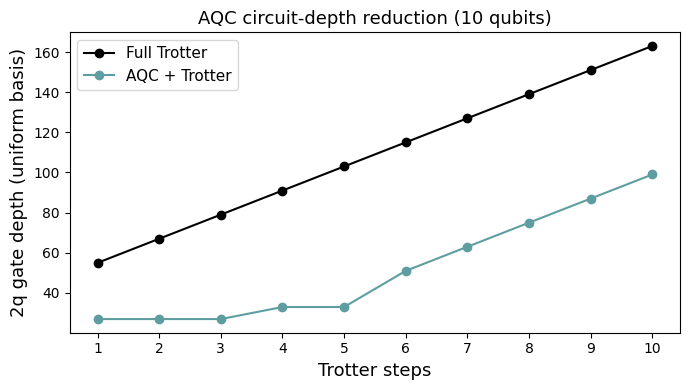

In [3]:
# Number of time steps to compress into an AQC ansatz with one layer
aqc_n_steps_1 = 3
# Number of time steps to compress into an AQC ansatz with two layers
aqc_n_steps_2 = 2
aqc_n_steps_total = aqc_n_steps_1 + aqc_n_steps_2

# ── Step 2a: Target circuits (first aqc_n_steps_total circuits from Step 1) ──
target_circuits = {
    k: circuits[k - 1] for k in range(1, aqc_n_steps_total + 1)
}
# ── Step 2b: Compute target MPS ──
# Decompose PauliEvolutionGate to RXX/RYY/RZZ before passing to the AQC MPS
# backend, which does not understand PauliEvolutionGate natively.
aqc_sim = QuimbSimulator(
    quimb_circuit_factory=partial(
        qtn.CircuitMPS,
        gate_opts=dict(max_bond=mps_max_bond, cutoff=mps_cutoff),
    ),
    autodiff_backend="jax",
)
print("\nStep 2b — target MPS:")
target_mps = {}
for k in range(1, aqc_n_steps_total + 1):
    target_mps[k] = tensornetwork_from_circuit(
        target_circuits[k].decompose(["PauliEvolution"]), aqc_sim
    )
    print(f"  k={k}: max bond = {target_mps[k].psi.max_bond()}")

# ── Step 2c: Generate ansätze (one-layer and two-layer) and optimize parameters ──
ansatz_1, initial_params_1 = generate_ansatz_from_circuit(
    target_circuits[1].decompose(["PauliEvolution"]),
    qubits_initially_zero=True,
)
initial_params_1 = np.array(initial_params_1)
ansatz_2, initial_params_2 = generate_ansatz_from_circuit(
    target_circuits[2].decompose(["PauliEvolution"]),
    qubits_initially_zero=True,
)
initial_params_2 = np.array(initial_params_2)
print(
    f"\nStep 2c — one-layer ansatz: {ansatz_1.num_parameters} parameters, "
    f"2q depth (uniform basis) = {uniform_2q_depth(ansatz_1)}"
)
print(
    f"Step 2c — two-layer ansatz: {ansatz_2.num_parameters} parameters, "
    f"2q depth (uniform basis) = {uniform_2q_depth(ansatz_2)}"
)

aqc_circuits = {}
aqc_params = {}
for k in range(1, aqc_n_steps_total + 1):
    if k <= aqc_n_steps_1:
        ansatz, base_params = ansatz_1, initial_params_1
    else:
        ansatz, base_params = ansatz_2, initial_params_2
    # Warm-start from the previous step only within the same stage
    same_stage = (k - 1 >= 1) and (
        (k - 1 <= aqc_n_steps_1) == (k <= aqc_n_steps_1)
    )
    x0 = aqc_params[k - 1] if same_stage else base_params
    obj = MaximizeStateFidelity(target_mps[k], ansatz, aqc_sim)
    t0 = timeit.default_timer()
    result = scipy.optimize.minimize(
        obj.loss_function,
        x0,
        method="L-BFGS-B",
        jac=True,
        options=dict(maxiter=100),
    )
    elapsed = timeit.default_timer() - t0
    aqc_params[k] = result.x
    aqc_circuits[k] = ansatz.assign_parameters(result.x)
    print(
        f"  k={k}: fidelity = {1 - result.fun:.4f}, "
        f"2q depth (uniform basis) = "
        f"{uniform_2q_depth(aqc_circuits[k])}, "
        f"{elapsed:.1f}s"
    )

# ── Step 2d: Assemble full circuit set (AQC + Trotter) ──
all_circuits = []
for k in range(1, aqc_n_steps_total + 1):
    all_circuits.append(aqc_circuits[k])
base = aqc_circuits[aqc_n_steps_total]
for k in range(1, n_steps - aqc_n_steps_total + 1):
    circuit = base.copy()
    for instr in trotter_evolution(
        circuit.qubits, coupling, anisotropy, time_step, k
    ):
        circuit.append(instr)
    all_circuits.append(circuit)

full_depths = [
    uniform_2q_depth(circuits[k - 1]) for k in range(1, n_steps + 1)
]
aqc_depths = [uniform_2q_depth(circuit) for circuit in all_circuits]
full_2q = [
    circuits[k - 1].decompose(["PauliEvolution"]).num_nonlocal_gates()
    for k in range(1, n_steps + 1)
]
aqc_2q = [
    circuit.decompose(["PauliEvolution"]).num_nonlocal_gates()
    for circuit in all_circuits
]
print(f"\nStep 2d — assembled {len(all_circuits)} circuits")
print(
    f"  At step {n_steps} (uniform basis): "
    f"Trotter 2q depth = {full_depths[-1]}, AQC+Trotter 2q depth = {aqc_depths[-1]}; "
    f"2q gates: Trotter = {full_2q[-1]}, AQC+Trotter = {aqc_2q[-1]}"
)

steps_axis = np.arange(1, n_steps + 1)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(steps_axis, full_depths, "-o", color="black", label="Full Trotter")
ax.plot(
    steps_axis, aqc_depths, "-o", color="cadetblue", label="AQC + Trotter"
)
ax.set_xlabel("Trotter steps", fontsize=13)
ax.xaxis.set_major_locator(plt.matplotlib.ticker.MaxNLocator(integer=True))
ax.set_ylabel("2q gate depth (uniform basis)", fontsize=13)
ax.set_title(f"AQC circuit-depth reduction ({n_qubits} qubits)", fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


### Step 3: Execute using Qiskit primitives

We simulate each AQC-compiled circuit using the `StatevectorEstimator` primitive.

In [4]:
estimator = StatevectorEstimator()
pubs = [(circuit, observables) for circuit in all_circuits]
job = estimator.run(pubs)
result = job.result()

### Step 4: Post-process and return result in desired classical format

We now  extract the expectation value $\langle\sigma_i^z\rangle$ for every qubit $i$ at each time step $t$. These values form the retarded Green's function matrix $G^R(j, j_c, t)$. Then, we Fourier-transform the RGF into the dynamical structure factor $S(q, \omega)$ and plot both the RGF and the DSF. `get_dsf` applies mirror symmetry and clips negative values internally.

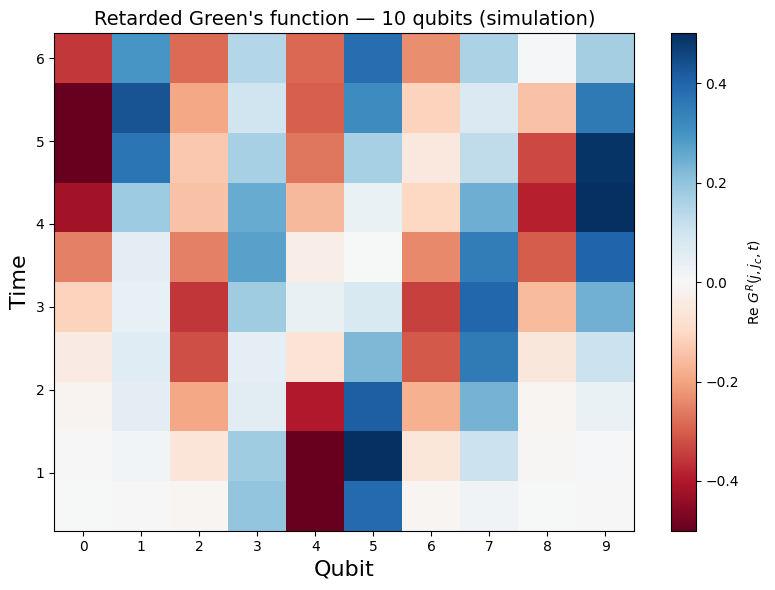

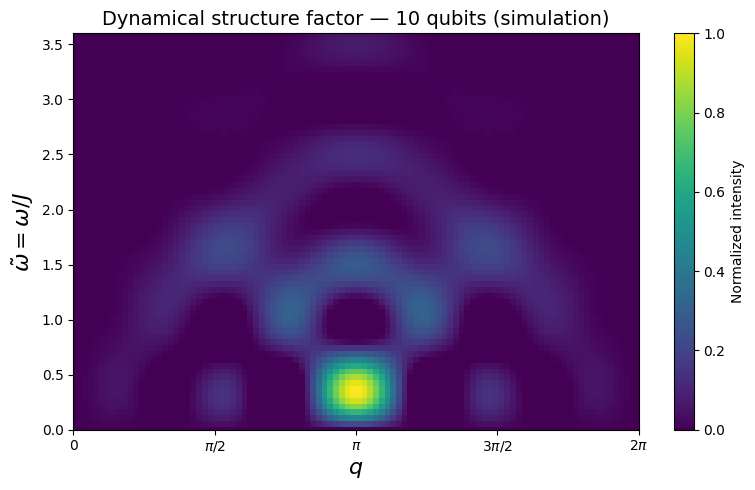

In [5]:
rgf_mat = np.stack([pub_result.data.evs for pub_result in result])

# -- Compute DSF --
n_points_momentum, n_points_frequency = 100, 100
spectrum = get_dsf(
    n_qubits,
    rgf_mat,
    time_step,
    n_steps,
    n_points_momentum,
    n_points_frequency,
)

# -- Plot retarded Green's function --
plot_rgf(
    n_qubits,
    rgf_mat,
    time_step,
    n_steps,
    title=f"Retarded Green's function — {n_qubits} qubits (simulation)",
)

# -- Plot DSF --
plot_dsf(
    spectrum,
    time_step,
    n_points_momentum,
    n_points_frequency,
    title=f"Dynamical structure factor — {n_qubits} qubits (simulation)",
)

## Large-scale hardware execution

We now scale up to **20 qubits**. Note that the paper scaled to 50 qubits, but reaching that scale required a large amount of computational resources to run AQC.

The code below follows the same four-step structure as the small-scale example. The HVA ground-state parameters are again optimized via MPS simulation. The following table summarizes how the large-scale experiment differs from the small-scale one:

| | Small scale | Large scale |
|---|---|---|
| Qubits | 10 | 20 |
| Time steps | 10 | 20 |
| AQC checkpoints (1-layer + 2-layer) | 3 + 2 = 5 | 6 + 4 = 10 |
| Ground state ansatz layers | 3 | 5 |
| MPS max bond dimension | 32 | 64 |
| Estimator | `StatevectorEstimator` | QPU with DD + Pauli twirling + TREX |


Ground-state energy (DMRG): -8.682473
Optimizing ground state ansatz...
Finished optimizing ground state ansatz in 39.46691244991962 seconds.
Ground state ansatz fidelity: 0.909073
Ground state ansatz energy: -8.581397
Built 20 circuits, deepest 2q depth (uniform basis) = 307
Defined 20 Z observables.

Step 2b — target MPS:
  k=1: max bond = 31
  k=2: max bond = 33
  k=3: max bond = 37
  k=4: max bond = 43
  k=5: max bond = 51
  k=6: max bond = 61
  k=7: max bond = 64
  k=8: max bond = 64
  k=9: max bond = 64
  k=10: max bond = 64

Step 2c — one-layer ansatz: 1156 parameters, 2q depth (uniform basis) = 39
Step 2c — two-layer ansatz: 1327 parameters, 2q depth (uniform basis) = 45
  k=1: fidelity = 1.0000, 2q depth (uniform basis) = 39, 47.3s
  k=2: fidelity = 0.9945, 2q depth (uniform basis) = 39, 56.9s
  k=3: fidelity = 0.9894, 2q depth (uniform basis) = 39, 56.1s
  k=4: fidelity = 0.9843, 2q depth (uniform basis) = 39, 55.4s
  k=5: fidelity = 0.9774, 2q depth (uniform basis) = 39, 58.

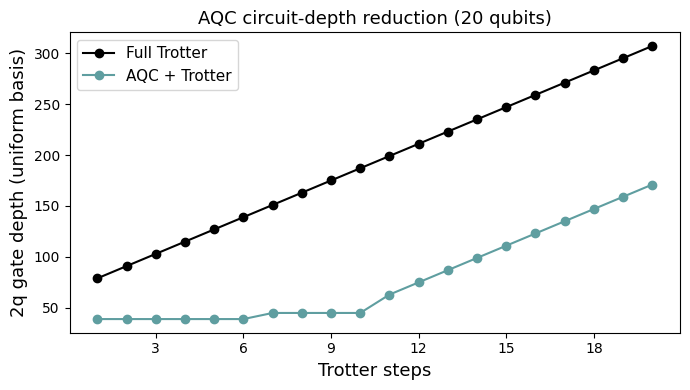

Backend: ibm_kingston
Transpiled 2q depth (deepest, ISA on ibm_kingston): 105 (2q gates: 999)
Job ID: d8uq0t8pknjs739voulg


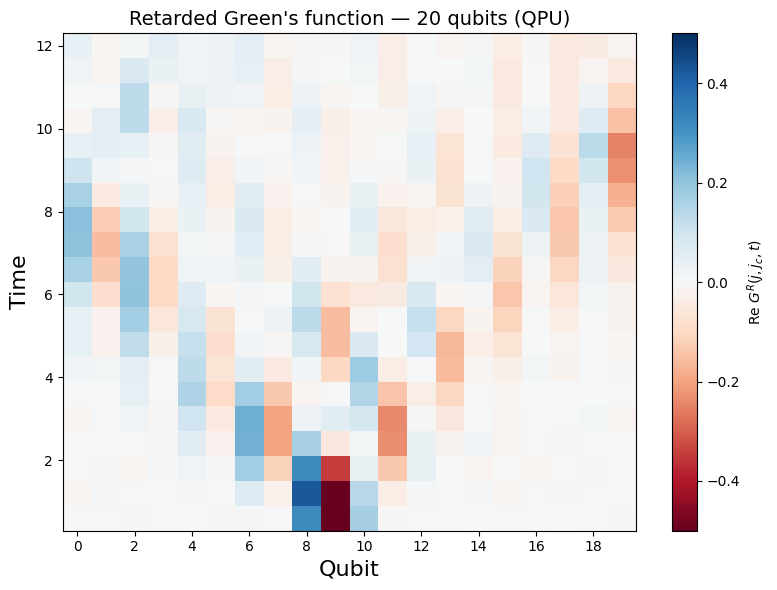

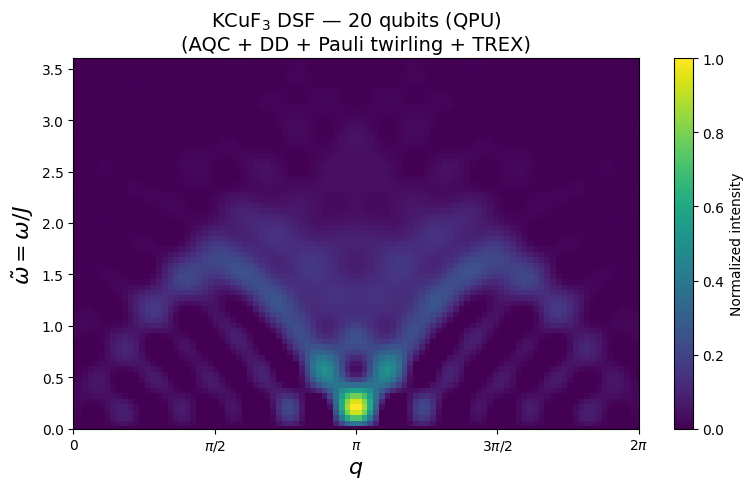

In [6]:
# ── Parameters ──────────────────────────────────────────────────────────────
n_qubits = 20  # 10 → 20
coupling = 1.0  # J
anisotropy = 1.0  # ε (isotropic point)
time_step = 0.6
n_steps = 20  # 10 → 20
aqc_n_steps_1 = 6  # 3 → 6
aqc_n_steps_2 = 4  # 2 → 4
aqc_n_steps_total = aqc_n_steps_1 + aqc_n_steps_2
gs_n_layers = 5  # 3 → 5
mps_max_bond = 64  # 32 -> 64
mps_cutoff = 1e-8
center = n_qubits // 2 - 1

# ── Step 1: Map ──────────────────────────────────────────────────────────────
ham_mpo = xxz_hamiltonian_mpo(n_qubits, coupling, anisotropy)

dmrg = qtn.DMRG2(ham_mpo)
dmrg.solve(tol=1e-8)
print(f"Ground-state energy (DMRG): {dmrg.energy:.6f}")

gs_ansatz = build_ground_state_ansatz(n_qubits, gs_n_layers)

rng = np.random.default_rng(12345)
x0_init = np.tile([0.0, np.pi / 2], gs_n_layers) + rng.normal(
    scale=0.1, size=2 * gs_n_layers
)
print("Optimizing ground state ansatz...")
t0 = timeit.default_timer()
result = optimize_ground_state_ansatz(
    gs_ansatz,
    x0_init,
    dmrg.state,
    max_bond=mps_max_bond,
    cutoff=mps_cutoff,
    options=dict(maxiter=100),
)
t1 = timeit.default_timer()
print(f"Finished optimizing ground state ansatz in {t1 - t0} seconds.")
print(f"Ground state ansatz fidelity: {1 - result.fun:.6f}")

gs_circuit = gs_ansatz.assign_parameters(result.x)
gs_circuit_mps = quimb_circuit(
    gs_circuit.decompose(["PauliEvolution"]),
    quimb_circuit_class=qtn.CircuitMPS,
    max_bond=mps_max_bond,
    cutoff=mps_cutoff,
)
gs_ansatz_energy = qtn.expec_TN_1D(
    gs_circuit_mps.psi.H, ham_mpo, gs_circuit_mps.psi
)
print(f"Ground state ansatz energy: {gs_ansatz_energy:.6f}")

perturbed = gs_circuit.copy()
perturbed.rz(np.pi / 2, center)

circuits = []
for t in range(1, n_steps + 1):
    circuit = perturbed.copy()
    for instr in trotter_evolution(
        circuit.qubits, coupling, anisotropy, time_step, t
    ):
        circuit.append(instr)
    circuits.append(circuit)
print(
    f"Built {len(circuits)} circuits, deepest 2q depth (uniform basis) = "
    f"{uniform_2q_depth(circuits[-1])}"
)

observables = [
    SparsePauliOp.from_sparse_list([("Z", [i], 1)], num_qubits=n_qubits)
    for i in range(n_qubits)
]
print(f"Defined {len(observables)} Z observables.")

# ── Step 2: AQC ──────────────────────────────────────────────────────────────
target_circuits = {
    k: circuits[k - 1] for k in range(1, aqc_n_steps_total + 1)
}

aqc_sim = QuimbSimulator(
    quimb_circuit_factory=partial(
        qtn.CircuitMPS,
        gate_opts=dict(max_bond=mps_max_bond, cutoff=mps_cutoff),
    ),
    autodiff_backend="jax",
)
print("\nStep 2b — target MPS:")
target_mps = {}
for k in range(1, aqc_n_steps_total + 1):
    target_mps[k] = tensornetwork_from_circuit(
        target_circuits[k].decompose(["PauliEvolution"]), aqc_sim
    )
    print(f"  k={k}: max bond = {target_mps[k].psi.max_bond()}")

ansatz_1, initial_params_1 = generate_ansatz_from_circuit(
    target_circuits[1].decompose(["PauliEvolution"]),
    qubits_initially_zero=True,
)
initial_params_1 = np.array(initial_params_1)
ansatz_2, initial_params_2 = generate_ansatz_from_circuit(
    target_circuits[2].decompose(["PauliEvolution"]),
    qubits_initially_zero=True,
)
initial_params_2 = np.array(initial_params_2)
print(
    f"\nStep 2c — one-layer ansatz: {ansatz_1.num_parameters} parameters, "
    f"2q depth (uniform basis) = {uniform_2q_depth(ansatz_1)}"
)
print(
    f"Step 2c — two-layer ansatz: {ansatz_2.num_parameters} parameters, "
    f"2q depth (uniform basis) = {uniform_2q_depth(ansatz_2)}"
)

aqc_circuits = {}
aqc_params = {}
for k in range(1, aqc_n_steps_total + 1):
    if k <= aqc_n_steps_1:
        ansatz, base_params = ansatz_1, initial_params_1
    else:
        ansatz, base_params = ansatz_2, initial_params_2
    # Warm-start from the previous step only within the same stage
    same_stage = (k - 1 >= 1) and (
        (k - 1 <= aqc_n_steps_1) == (k <= aqc_n_steps_1)
    )
    x0 = aqc_params[k - 1] if same_stage else base_params
    obj = MaximizeStateFidelity(target_mps[k], ansatz, aqc_sim)
    t0 = timeit.default_timer()
    result = scipy.optimize.minimize(
        obj.loss_function,
        x0,
        method="L-BFGS-B",
        jac=True,
        options=dict(maxiter=100),
    )
    elapsed = timeit.default_timer() - t0
    aqc_params[k] = result.x
    aqc_circuits[k] = ansatz.assign_parameters(result.x)
    print(
        f"  k={k}: fidelity = {1 - result.fun:.4f}, "
        f"2q depth (uniform basis) = "
        f"{uniform_2q_depth(aqc_circuits[k])}, "
        f"{elapsed:.1f}s"
    )

all_circuits = []
for k in range(1, aqc_n_steps_total + 1):
    all_circuits.append(aqc_circuits[k])
base = aqc_circuits[aqc_n_steps_total]
for k in range(1, n_steps - aqc_n_steps_total + 1):
    circuit = base.copy()
    for instr in trotter_evolution(
        circuit.qubits, coupling, anisotropy, time_step, k
    ):
        circuit.append(instr)
    all_circuits.append(circuit)

full_depths = [
    uniform_2q_depth(circuits[k - 1]) for k in range(1, n_steps + 1)
]
aqc_depths = [uniform_2q_depth(circuit) for circuit in all_circuits]
full_2q = [
    circuits[k - 1].decompose(["PauliEvolution"]).num_nonlocal_gates()
    for k in range(1, n_steps + 1)
]
aqc_2q = [
    circuit.decompose(["PauliEvolution"]).num_nonlocal_gates()
    for circuit in all_circuits
]
print(f"\nStep 2d — assembled {len(all_circuits)} circuits")
print(
    f"  At step {n_steps} (uniform basis): "
    f"Trotter 2q depth = {full_depths[-1]}, AQC+Trotter 2q depth = {aqc_depths[-1]}; "
    f"2q gates: Trotter = {full_2q[-1]}, AQC+Trotter = {aqc_2q[-1]}"
)

steps_axis = np.arange(1, n_steps + 1)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(steps_axis, full_depths, "-o", color="black", label="Full Trotter")
ax.plot(
    steps_axis, aqc_depths, "-o", color="cadetblue", label="AQC + Trotter"
)
ax.set_xlabel("Trotter steps", fontsize=13)
ax.xaxis.set_major_locator(plt.matplotlib.ticker.MaxNLocator(integer=True))
ax.set_ylabel("2q gate depth (uniform basis)", fontsize=13)
ax.set_title(f"AQC circuit-depth reduction ({n_qubits} qubits)", fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# ── Step 3: Execute on IBM Quantum hardware ───────────────────────────────────
# (replaces StatevectorEstimator)
service = QiskitRuntimeService()
backend = service.least_busy(
    min_num_qubits=n_qubits,
    operational=True,
    simulator=False,
    filters=lambda x: x.configuration().processor_type["family"] == "Heron",
)
print(f"Backend: {backend.name}")

pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
isa_circuits = pm.run(all_circuits, num_processes=1)
isa_2q_depths = [
    isa_circuit.depth(lambda inst: inst.operation.num_qubits == 2)
    for isa_circuit in isa_circuits
]
print(
    f"Transpiled 2q depth (deepest, ISA on {backend.name}): "
    f"{max(isa_2q_depths)} "
    f"(2q gates: {max(isa_circuit.num_nonlocal_gates() for isa_circuit in isa_circuits)})"
)

estimator = Estimator(backend)
estimator.options.dynamical_decoupling.enable = True
estimator.options.dynamical_decoupling.sequence_type = "XY4"
estimator.options.twirling.enable_gates = True
estimator.options.twirling.num_randomizations = 1000
estimator.options.twirling.shots_per_randomization = 128
estimator.options.resilience.measure_mitigation = True
estimator.options.resilience.measure_noise_learning.num_randomizations = 32
estimator.options.resilience.measure_noise_learning.shots_per_randomization = 100

pubs = [
    (
        isa_circuit,
        [obs.apply_layout(isa_circuit.layout) for obs in observables],
    )
    for isa_circuit in isa_circuits
]
job = estimator.run(pubs)
print(f"Job ID: {job.job_id()}")

result = job.result()

# ── Step 4: Post-process ──────────────────────────────────────────────────────
rgf_mat = np.stack([pub_result.data.evs for pub_result in result])

n_points_momentum, n_points_frequency = 100, 100
spectrum = get_dsf(
    n_qubits,
    rgf_mat,
    time_step,
    n_steps,
    n_points_momentum,
    n_points_frequency,
)

plot_rgf(
    n_qubits,
    rgf_mat,
    time_step,
    n_steps,
    title=f"Retarded Green's function — {n_qubits} qubits (QPU)",
)
plot_dsf(
    spectrum,
    time_step,
    n_points_momentum,
    n_points_frequency,
    title=rf"KCuF$_3$ DSF — {n_qubits} qubits (QPU)"
    "\n(AQC + DD + Pauli twirling + TREX)",
)


## Next steps
If you found this work interesting, you might be interested in the following material:
<Admonition type="tip" title="Recommendations">

- [Lee et al., "Benchmarking quantum simulation with neutron-scattering experiments" (arXiv:2603.15608)](https://arxiv.org/abs/2603.15608) — the reference paper this tutorial is based on
- [Error Suppression and Mitigation with Qiskit Runtime](https://docs.quantum.ibm.com/guides/error-mitigation-and-suppression-techniques) — DD, Pauli twirling, and TREX used in the hardware experiments
- [Approximate quantum compilation for time evolution circuits](https://quantum.cloud.ibm.com/docs/en/tutorials/approximate-quantum-compilation-for-time-evolution) — tutorial on AQC-Tensor
- [AQC-Tensor documentation](https://qiskit.github.io/qiskit-addon-aqc-tensor/)

</Admonition>